# EUR/USD Time Series Forecasting with Neural Networks
**Financial Data Analytics — Part B**

This notebook applies neural network architectures to forecast EUR/USD 5-minute returns using combined Bid and Ask price data from Dukascopy.

**Models covered:** Dense (MLP) · LSTM · GRU (with hyperparameter search) · Transformer Encoder


## Section 1 — Imports & Configuration

In [49]:
# Import all required libraries for data processing, visualisation,
# machine learning preprocessing, and neural network construction.
# Each library serves a specific role — numpy/pandas handle numerical
# and tabular data, matplotlib/seaborn produce charts, torch provides
# the neural network framework, and sklearn supplies scaling and metrics.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import random
import os
import types

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
print("Libraries imported successfully.")


Libraries imported successfully.


In [50]:
# Set random seeds for Python, NumPy, and PyTorch, and detect
# whether a GPU is available for training.
# Neural network weights are randomly initialised. Without fixing
# the seed, results differ on every run, making experiments
# impossible to reproduce or compare fairly. GPU acceleration
# (CUDA) can reduce training time significantly on large datasets.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [51]:
# Define all training hyperparameters in a single configuration block.
# Centralising hyperparameters means they only need to be changed in
# one place. This prevents inconsistencies where, for example, one
# model trains for a different number of epochs than another.
# WINDOW_SIZE controls how many past timesteps form one input sample.
# EPOCHS caps total training iterations. PATIENCE controls early
# stopping — training halts if validation loss does not improve for
# this many consecutive epochs. LEARNING_RATE controls the step size
# of the Adam optimiser during gradient descent.

WINDOW_SIZE   = 20
BATCH_SIZE    = 64
EPOCHS        = 50
PATIENCE      = 15
LEARNING_RATE = 1e-3

print(f"Window: {WINDOW_SIZE} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | Patience: {PATIENCE} | LR: {LEARNING_RATE}")


Window: 20 | Batch: 64 | Epochs: 50 | Patience: 15 | LR: 0.001


## Section 2 — Data Loading & Bid/Ask Combination

In [53]:
# Load both CSV files and immediately strip whitespace from all column names
# Dukascopy exports column names with trailing spaces which causes KeyError on merge
df_bid = pd.read_csv(BID_PATH)
df_ask = pd.read_csv(ASK_PATH)

df_bid.columns = df_bid.columns.str.strip()
df_ask.columns = df_ask.columns.str.strip()

print("Bid shape:", df_bid.shape)
print("Ask shape:", df_ask.shape)
df_bid.head(3)

Bid shape: (36984, 6)
Ask shape: (36984, 6)


,Time (EET),Open,High,Low,Close,Volume
0,2025.10.01 00:00:00,1.17325,1.17339,1.17325,1.17339,34.53
1,2025.10.01 00:05:00,1.17341,1.17350,1.17338,1.17343,33.60
2,2025.10.01 00:10:00,1.17343,1.17348,1.17328,1.17335,103.47


In [54]:
# Rename the time column, parse it as a datetime, and prefix all
# OHLCV columns to identify whether they come from Bid or Ask.
# After merging the two DataFrames, column names would clash unless
# they are prefixed. Parsing the time column as datetime allows
# chronological sorting and time-aware operations later.

df_bid = df_bid.rename(columns={"Time (EET)": "Time"})
df_ask = df_ask.rename(columns={"Time (EET)": "Time"})

df_bid["Time"] = pd.to_datetime(df_bid["Time"])
df_ask["Time"] = pd.to_datetime(df_ask["Time"])

bid_cols = {"Open": "Bid_Open", "High": "Bid_High", "Low": "Bid_Low",
            "Close": "Bid_Close", "Volume": "Bid_Volume"}
ask_cols = {"Open": "Ask_Open", "High": "Ask_High", "Low": "Ask_Low",
            "Close": "Ask_Close", "Volume": "Ask_Volume"}

df_bid = df_bid.rename(columns=bid_cols)
df_ask = df_ask.rename(columns=ask_cols)

print("Bid columns:", df_bid.columns.tolist())
print("Ask columns:", df_ask.columns.tolist())


Bid columns: ['Time', 'Bid_Open', 'Bid_High', 'Bid_Low', 'Bid_Close', 'Bid_Volume']
Ask columns: ['Time', 'Ask_Open', 'Ask_High', 'Ask_Low', 'Ask_Close', 'Ask_Volume']


In [55]:
# Inner-join the Bid and Ask DataFrames on the shared Time column
# and sort chronologically.
# An inner join keeps only timestamps that exist in both files,
# avoiding NaN values caused by missing bars in either stream.
# Chronological order is required for the time-based train/val/test
# split performed later.

df = pd.merge(df_bid, df_ask, on="Time", how="inner")
df = df.sort_values("Time").reset_index(drop=True)

print("Merged shape:", df.shape)
print("Time range:", df["Time"].min(), "→", df["Time"].max())
df.head(3)


Merged shape: (36984, 11)
Time range: 2025-10-01 00:00:00 → 2026-03-31 23:55:00


,Time,Bid_Open,Bid_High,Bid_Low,Bid_Close,Bid_Volume,Ask_Open,Ask_High,Ask_Low,Ask_Close,Ask_Volume
0,2025-10-01 00:00:00,1.17325,1.17339,1.17325,1.17339,34.53,1.17347,1.17398,1.17347,1.17387,25.17
1,2025-10-01 00:05:00,1.17341,1.17350,1.17338,1.17343,33.60,1.17387,1.17397,1.17385,1.17386,18.73
2,2025-10-01 00:10:00,1.17343,1.17348,1.17328,1.17335,103.47,1.17392,1.17392,1.17352,1.17384,37.35


In [56]:
# Compute mid-prices, the bid-ask spread, spread in pips, and
# combined volume from the two price streams.
# The mid-price (average of Bid and Ask) is the fairest estimate
# of the true market price because it is not biased toward either
# the buyer or the seller. The spread (Ask minus Bid) directly
# measures market liquidity — a widening spread signals lower
# liquidity and higher uncertainty, which is itself a predictive
# signal. For EUR/USD, multiplying by 10,000 converts the spread
# to the conventional pip unit. Combined volume aggregates total
# market activity from both sides.

df["Mid_Open"]     = (df["Bid_Open"]  + df["Ask_Open"])  / 2
df["Mid_High"]     = (df["Bid_High"]  + df["Ask_High"])  / 2
df["Mid_Low"]      = (df["Bid_Low"]   + df["Ask_Low"])   / 2
df["Mid_Close"]    = (df["Bid_Close"] + df["Ask_Close"]) / 2

df["spread"]       = df["Ask_Close"] - df["Bid_Close"]
df["spread_pct"]   = df["spread"] / df["Mid_Close"] * 10000

df["total_volume"] = df["Bid_Volume"] + df["Ask_Volume"]

print("Mid and spread columns created.")
df[["Mid_Close", "spread", "spread_pct", "total_volume"]].describe()


Mid and spread columns created.


,Mid_Close,spread,spread_pct,total_volume
count,36984.000000,36984.000000,36984.000000,36984.000000
mean,1.167163,0.000049,0.418725,791.799421
std,0.011636,0.000082,0.697042,737.414854
min,1.141140,0.000010,0.083091,0.000000
25%,1.158700,0.000020,0.172870,318.135000
50%,1.164810,0.000040,0.338427,583.685000
75%,1.175445,0.000050,0.425336,1024.297500
max,1.205610,0.002540,21.556846,10354.020000


## Section 3 — Exploratory Data Analysis

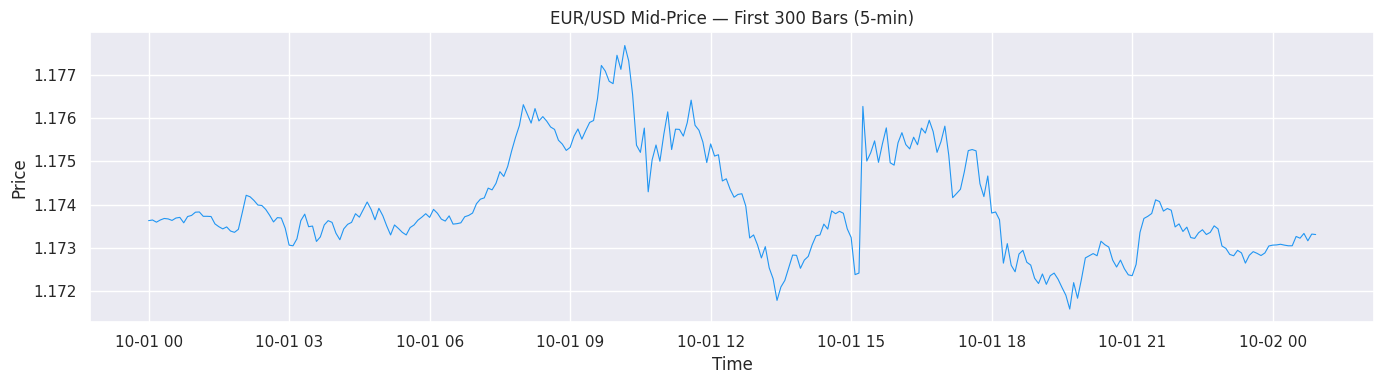

In [57]:
# Plot the EUR/USD mid-price as a Japanese candlestick chart
#       with volume bars in a lower panel.
# Candlestick charts are the standard visualisation in financial
#       markets. Each candle encodes four prices (Open, High, Low, Close)
#       into a single visual element, making price action, trends, and
#       volatility immediately visible. Volume shows market participation
#       alongside price movement.
# mplfinance.plot() accepts a DataFrame with OHLCV columns and a
#       DatetimeIndex. The "charles" style uses green/red candles.
#       A plain line chart is used as a fallback if mplfinance is absent.

try:
    import mplfinance as mpf

    df_candle = df.set_index("Time")[["Mid_Open","Mid_High","Mid_Low","Mid_Close","total_volume"]].iloc[:300].copy()
    df_candle.columns = ["Open","High","Low","Close","Volume"]
    df_candle.index.name = "Date"

    mpf.plot(df_candle, type="candle", volume=True, style="charles",
             title="EUR/USD Mid-Price — First 300 Bars (5-min)",
             ylabel="Price (EUR/USD)", ylabel_lower="Volume",
             figsize=(14, 6))
except ImportError:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["Time"].iloc[:300], df["Mid_Close"].iloc[:300], color="#2196F3", lw=0.8)
    ax.set_title("EUR/USD Mid-Price — First 300 Bars (5-min)")
    ax.set_xlabel("Time"); ax.set_ylabel("Price")
    plt.tight_layout(); plt.show()


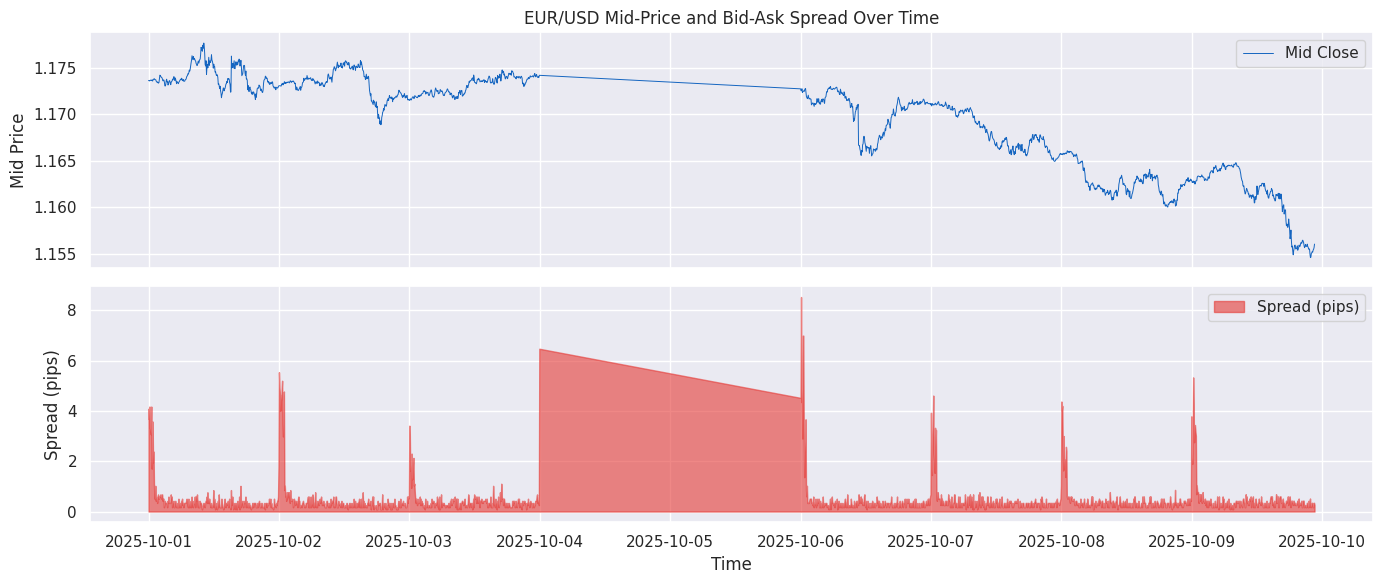

In [58]:
# Plot mid-price and bid-ask spread on a shared time axis
#       to show how liquidity varies alongside price.
# Spread is not constant — it widens during low-liquidity periods
#       such as market open, news events, and overnight sessions.
#       Showing both together reveals whether spread changes coincide
#       with price volatility, which informs which features are most
#       informative for the model.
# Two vertically stacked subplots share an x-axis (sharex=True).
#       fill_between shades the spread area, making size changes
#       more visually prominent than a plain line.

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df["Time"].iloc[:2000], df["Mid_Close"].iloc[:2000],
             color="#1565C0", lw=0.7, label="Mid Close")
axes[0].set_ylabel("Mid Price"); axes[0].legend()
axes[0].set_title("EUR/USD Mid-Price and Bid-Ask Spread Over Time")

axes[1].fill_between(df["Time"].iloc[:2000], df["spread_pct"].iloc[:2000],
                     color="#E53935", alpha=0.6, label="Spread (pips)")
axes[1].set_ylabel("Spread (pips)"); axes[1].legend()
axes[1].set_xlabel("Time")

plt.tight_layout(); plt.show()


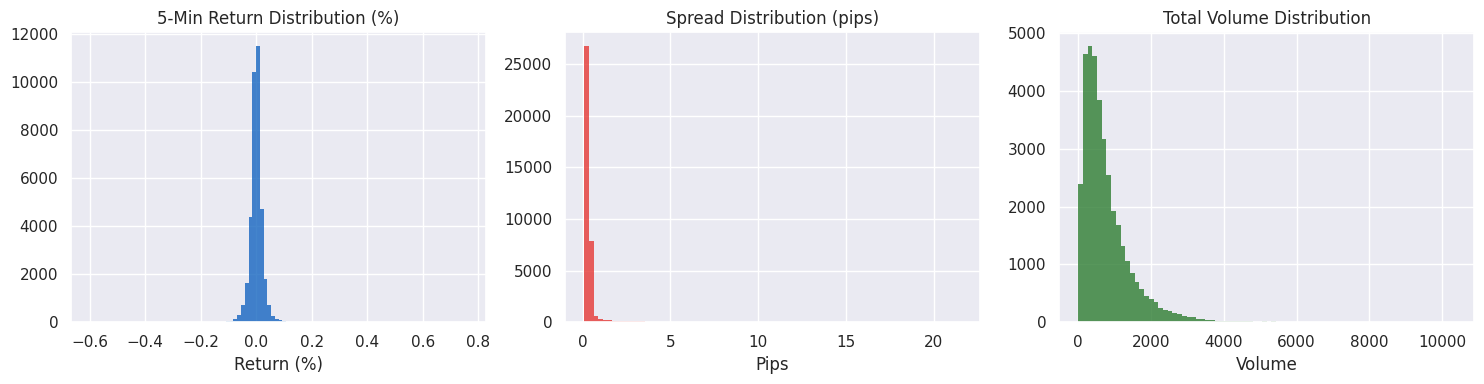

In [59]:
# Plot histograms of the 5-minute return distribution, the spread
#       distribution, and the volume distribution side by side.
# Understanding the statistical shape of the target variable (returns)
#       and input features is essential before modelling. Returns in
#       financial markets are typically near-normally distributed with
#       fat tails. Spreads and volumes are typically right-skewed.
#       These shapes influence scaling choices and expected model behaviour.
# Three subplots are created in one row. pct_change() computes
#       the percentage price change between consecutive bars. shift(-1)
#       is not applied here because we just want the distribution, not
#       the forecast target.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["Mid_Close"].pct_change().dropna() * 100, bins=100,
             color="#1565C0", edgecolor="none", alpha=0.8)
axes[0].set_title("5-Min Return Distribution (%)"); axes[0].set_xlabel("Return (%)")

axes[1].hist(df["spread_pct"].dropna(), bins=80,
             color="#E53935", edgecolor="none", alpha=0.8)
axes[1].set_title("Spread Distribution (pips)"); axes[1].set_xlabel("Pips")

axes[2].hist(df["total_volume"].dropna(), bins=80,
             color="#2E7D32", edgecolor="none", alpha=0.8)
axes[2].set_title("Total Volume Distribution"); axes[2].set_xlabel("Volume")

plt.tight_layout(); plt.show()


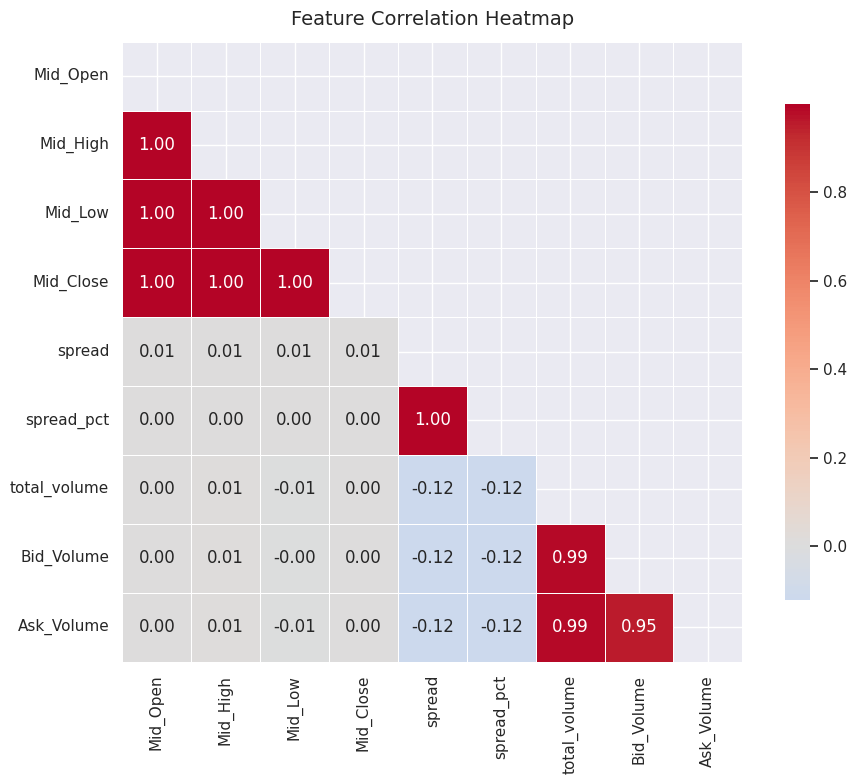

In [60]:
# Compute and display a lower-triangular Pearson correlation heatmap
#       for the main price, spread, and volume columns.
# Highly correlated features carry redundant information.
#       Identifying correlations helps us understand which features
#       are genuinely independent signals versus duplicates. For example,
#       Bid_Volume and Ask_Volume may be so correlated that keeping both
#       adds noise rather than signal.
# df.corr() computes pairwise Pearson correlations. np.triu masks
#       the upper triangle to avoid showing each pair twice.
#       The coolwarm colormap shows positive correlations in red and
#       negative correlations in blue, centred at zero.

corr_cols = ["Mid_Open","Mid_High","Mid_Low","Mid_Close",
             "spread","spread_pct","total_volume",
             "Bid_Volume","Ask_Volume"]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14, pad=12)
plt.tight_layout(); plt.show()


## Section 4 — Feature Engineering

In [61]:
# Create the forecast target — the percentage return of the next bar.
# We want the model to predict what happens NEXT, not what is
#       happening now. pct_change() gives the return for the current bar;
#       shift(-1) moves it one row earlier so that row i's target is the
#       return that occurs at row i+1. Forecasting returns rather than
#       raw prices is standard practice because returns are stationary
#       (they do not trend indefinitely), which makes them much easier
#       for a neural network to learn.
# pct_change() computes (Close[t] - Close[t-1]) / Close[t-1].
#       shift(-1) aligns the next bar's return to the current row.

df["return"]     = df["Mid_Close"].pct_change().shift(-1)
df["log_return"] = np.log(df["Mid_Close"] / df["Mid_Close"].shift(1))

print("Return columns created.")


Return columns created.


In [62]:
# Engineer candle structure features from the mid-price OHLC values.
# Raw OHLC prices are highly correlated with each other (High is
#       always close to Close). Derived candle features capture shape
#       information that is more informative and less redundant.
#       Range measures overall volatility within the bar. Body measures
#       the net direction and strength of price movement. Upper and lower
#       wicks reveal rejection of higher/lower prices — a key signal in
#       Japanese candlestick pattern analysis.
# Element-wise subtraction on pandas columns. max/min across
#       Open and Close selects the top/bottom of the candle body.

df["range"]      = df["Mid_High"] - df["Mid_Low"]
df["body"]       = df["Mid_Close"] - df["Mid_Open"]
df["upper_wick"] = df["Mid_High"] - df[["Mid_Open","Mid_Close"]].max(axis=1)
df["lower_wick"] = df[["Mid_Open","Mid_Close"]].min(axis=1) - df["Mid_Low"]

print("Candle structure features created.")


Candle structure features created.


In [63]:
# Add moving averages of 5, 10, and 20 periods and a moving
#       average crossover signal.
# Moving averages smooth out short-term noise and reveal the
#       underlying trend direction. A crossover between a fast MA
#       (5-period) and a slow MA (10-period) is one of the most widely
#       used trend signals in technical analysis — a positive value means
#       the fast MA is above the slow MA, indicating upward momentum.
# rolling(n).mean() computes the unweighted average of the last
#       n observations. The crossover is the arithmetic difference between
#       the two MAs, giving a continuous-valued trend indicator.

df["ma_5"]    = df["Mid_Close"].rolling(5).mean()
df["ma_10"]   = df["Mid_Close"].rolling(10).mean()
df["ma_20"]   = df["Mid_Close"].rolling(20).mean()
df["ma_cross"] = df["ma_5"] - df["ma_10"]

print("Moving average features created.")


Moving average features created.


In [64]:
# Compute rolling volatility (standard deviation of log returns)
#       over 5 and 10 periods.
# Volatility is a core concept in financial markets. High volatility
#       periods are harder to predict and carry more risk. Including
#       realised volatility as a feature allows the model to adapt its
#       predictions to the current market regime — behaving differently
#       during calm vs turbulent periods.
# log_return is used rather than raw returns because log returns
#       are additive over time and more normally distributed.
#       rolling().std() computes the standard deviation of the past n
#       log returns, which is the standard definition of realised volatility.

df["vol_5"]  = df["log_return"].rolling(5).std()
df["vol_10"] = df["log_return"].rolling(10).std()

print("Volatility features created.")


Volatility features created.


In [65]:
# Compute the 14-period Relative Strength Index (RSI).
# RSI is a momentum oscillator that measures the speed and magnitude
#       of recent price changes on a scale of 0 to 100. Values above 70
#       suggest the asset is overbought (price may reverse downward);
#       values below 30 suggest it is oversold (price may reverse upward).
#       Including RSI gives the model an encoded momentum signal that would
#       otherwise take many raw bars to detect implicitly.
# The classic Wilder RSI formula separates price changes into gains
#       and losses, takes 14-period rolling averages of each, and computes
#       RS = average gain / average loss. RSI = 100 - (100 / (1 + RS)).
#       A small epsilon (1e-8) prevents division by zero.

delta = df["Mid_Close"].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / (loss + 1e-8)
df["rsi_14"] = 100 - (100 / (1 + rs))

print("RSI-14 created.")


RSI-14 created.


In [66]:
# Add lagged spread features and a bid/ask volume ratio.
# Spread changes do not only matter at the current bar — their
#       recent history (lag 1 and lag 2) reveals whether liquidity is
#       improving or deteriorating. The volume ratio (Bid / Ask volume)
#       measures order flow imbalance: a ratio above 1 means more sell-side
#       (bid) volume, indicating selling pressure; below 1 means buying
#       pressure. These microstructure features are not available in
#       single-stream (Bid-only) data, which is why combining both streams
#       adds measurable value.
# shift(1) and shift(2) create copies of the spread column offset
#       by one and two rows respectively. Division gives the volume ratio;
#       the epsilon prevents division by zero when Ask volume is zero.

df["spread_lag1"] = df["spread_pct"].shift(1)
df["spread_lag2"] = df["spread_pct"].shift(2)
df["vol_ratio"]   = df["Bid_Volume"] / (df["Ask_Volume"] + 1e-8)

df = df.dropna().reset_index(drop=True)
print("Microstructure features created.")
print("Dataset after feature engineering:", df.shape)


Microstructure features created.
Dataset after feature engineering: (36964, 34)


In [67]:
# Define the final list of input features and the target column.
# Explicitly listing feature columns makes it easy to add, remove,
#       or reorder features in one place without hunting through the code.
#       It also makes the feature set transparent and reproducible.
# feature_columns is passed to the scaler and sequence builder.
#       target_column is scaled and predicted separately because it
#       needs its own inverse transform at evaluation time.

feature_columns = [
    "Mid_Open", "Mid_High", "Mid_Low", "Mid_Close",
    "log_return", "range", "body", "upper_wick", "lower_wick",
    "ma_5", "ma_10", "ma_20", "ma_cross",
    "vol_5", "vol_10",
    "rsi_14",
    "spread", "spread_pct", "spread_lag1", "spread_lag2",
    "total_volume", "vol_ratio"
]

target_column = "return"

print(f"Total input features: {len(feature_columns)}")
df[feature_columns + [target_column]].describe().round(6)


Total input features: 22


,Mid_Open,Mid_High,Mid_Low,Mid_Close,log_return,range,body,upper_wick,lower_wick,ma_5,...,vol_5,vol_10,rsi_14,spread,spread_pct,spread_lag1,spread_lag2,total_volume,vol_ratio,return
count,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,...,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000,36964.000000
mean,1.167160,1.167335,1.166985,1.167160,-0.000000,0.000350,-0.000000,0.000084,0.000085,1.167161,...,0.000190,0.000198,49.883568,0.000049,0.417785,0.417787,0.417794,792.011514,1.051466,-0.000000
std,0.011638,0.011641,0.011635,0.011638,0.000241,0.000273,0.000275,0.000105,0.000099,0.011635,...,0.000152,0.000139,16.242380,0.000081,0.695334,0.695334,0.695334,737.420662,0.308861,0.000241
min,1.141160,1.141225,1.141095,1.141140,-0.006004,0.000000,-0.005480,0.000000,0.000000,1.141300,...,0.000000,0.000000,0.219285,0.000010,0.083091,0.083091,0.083091,0.000000,0.000000,-0.005986
25%,1.158695,1.158900,1.158515,1.158700,-0.000108,0.000190,-0.000125,0.000020,0.000020,1.158706,...,0.000100,0.000115,38.279784,0.000020,0.172867,0.172867,0.172867,318.407500,0.899085,-0.000108
50%,1.164810,1.164950,1.164660,1.164805,0.000000,0.000290,0.000000,0.000055,0.000055,1.164806,...,0.000154,0.000166,49.998232,0.000040,0.338418,0.338418,0.338418,583.835000,1.016616,0.000000
75%,1.175450,1.175615,1.175291,1.175445,0.000106,0.000435,0.000125,0.000115,0.000115,1.175435,...,0.000236,0.000242,61.435960,0.000050,0.425262,0.425262,0.425263,1024.375000,1.152249,0.000106
max,1.205615,1.208260,1.204100,1.205610,0.007575,0.013290,0.008715,0.004545,0.002800,1.204305,...,0.003604,0.002585,99.995189,0.002540,21.556846,21.556846,21.556846,10354.020000,12.667934,0.007604


## Section 5 — Train / Validation / Test Split, Scaling & Sequence Creation

In [68]:
# Split the dataset into training (70%), validation (15%), and
#       test (15%) sets in chronological order.
# Financial time series must never be split randomly. Random
#       splitting would allow the model to see future data during training
#       (data leakage), producing artificially low error metrics that do
#       not reflect real-world performance. A strict chronological split
#       ensures the model is always evaluated on data it has never seen.
#       The validation set is used to tune hyperparameters and trigger
#       early stopping; the test set is held out entirely until final
#       evaluation.
# Integer indices are calculated from the dataset length using
#       proportional fractions. iloc slices the DataFrame by position.

n         = len(df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Train: {len(train_df):,} rows ({train_end/n*100:.0f}%)")
print(f"Val:   {len(val_df):,} rows ({(val_end-train_end)/n*100:.0f}%)")
print(f"Test:  {len(test_df):,} rows ({(n-val_end)/n*100:.0f}%)")


Train: 25,874 rows (70%)
Val:   5,545 rows (15%)
Test:  5,545 rows (15%)


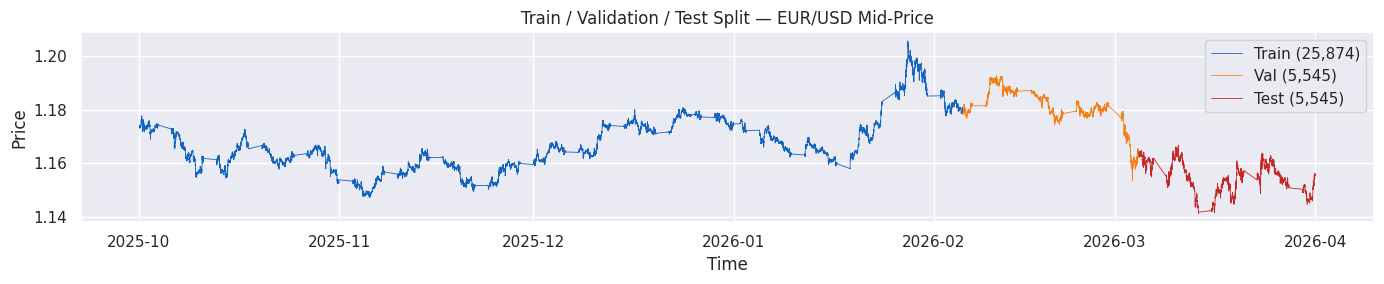

In [69]:
# Visualise the three data splits on the mid-price time series
#       using a different colour for each segment.
# A visual split confirmation ensures the proportions are correct
#       and makes the temporal boundaries clear. It also helps identify
#       whether the test set covers a meaningfully different market regime
#       (e.g., a trend vs sideways market) that would challenge the model.
# Three separate plot() calls on the same axes, each covering its
#       own segment of the time axis.

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(train_df["Time"], train_df["Mid_Close"], color="#1565C0", lw=0.6, label=f"Train ({len(train_df):,})")
ax.plot(val_df["Time"],   val_df["Mid_Close"],   color="#F57F17", lw=0.6, label=f"Val ({len(val_df):,})")
ax.plot(test_df["Time"],  test_df["Mid_Close"],  color="#C62828", lw=0.6, label=f"Test ({len(test_df):,})")
ax.set_title("Train / Validation / Test Split — EUR/USD Mid-Price")
ax.set_xlabel("Time"); ax.set_ylabel("Price"); ax.legend()
plt.tight_layout(); plt.show()


In [70]:
# Standardise (z-score normalise) input features and the target
#       variable using parameters computed only from the training set.
# Neural networks with sigmoid or ReLU activations are sensitive to
#       input scale. Features with large magnitudes (e.g., raw price ~1.08)
#       will dominate features with small magnitudes (e.g., spread ~0.0001)
#       unless both are brought to a common scale. StandardScaler transforms
#       each feature to have mean 0 and standard deviation 1.
#       Fitting ONLY on training data is essential — fitting on val or test
#       data would leak future statistics into the model (data leakage).
# fit() computes mean and std from the training split.
#       transform() applies the same mean/std to all three splits,
#       ensuring consistency.

feature_scaler = StandardScaler()
feature_scaler.fit(train_df[feature_columns])

train_scaled = feature_scaler.transform(train_df[feature_columns])
val_scaled   = feature_scaler.transform(val_df[feature_columns])
test_scaled  = feature_scaler.transform(test_df[feature_columns])

target_scaler = StandardScaler()
target_scaler.fit(train_df[[target_column]])

train_targets = target_scaler.transform(train_df[[target_column]]).flatten()
val_targets   = target_scaler.transform(val_df[[target_column]]).flatten()
test_targets  = target_scaler.transform(test_df[[target_column]]).flatten()

print("Feature range after scaling (train): [{:.4f}, {:.4f}]".format(train_scaled.min(), train_scaled.max()))
print("Target range after scaling  (train): [{:.4f}, {:.4f}]".format(train_targets.min(), train_targets.max()))


Feature range after scaling (train): [-22.0280, 39.8438]
Target range after scaling  (train): [-21.9756, 26.2263]


In [71]:
# Convert the scaled tabular data into overlapping sequences of
#       length WINDOW_SIZE for use as neural network inputs.
# Recurrent networks (LSTM, GRU) and the Transformer require input
#       in the shape (samples, timesteps, features). Each sample must
#       contain WINDOW_SIZE consecutive timesteps so the model can learn
#       temporal patterns across that window. A sliding window of step 1
#       maximises the number of training samples while preserving the full
#       temporal structure.
# For each valid index i (starting at WINDOW_SIZE), we take rows
#       i-WINDOW_SIZE to i as the input window and row i as the target.
#       The result is a 3D NumPy array of shape
#       (n_samples, WINDOW_SIZE, n_features).

def create_sequences(data, targets, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(targets[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, train_targets, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_scaled,   val_targets,   WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  test_targets,  WINDOW_SIZE)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  |  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  |  y_test:  {y_test.shape}")


X_train: (25854, 20, 22)  |  y_train: (25854,)
X_val:   (5525, 20, 22)  |  y_val:   (5525,)
X_test:  (5525, 20, 22)  |  y_test:  (5525,)


In [72]:
# Convert NumPy arrays into PyTorch tensors and wrap them in
#       DataLoader objects for mini-batch iteration during training.
# PyTorch's computational graph operates on Tensor objects, not
#       NumPy arrays. DataLoader handles batching, which means instead
#       of passing all data at once (which may not fit in GPU memory),
#       the model processes BATCH_SIZE samples at a time. shuffle=False
#       preserves temporal order — shuffling sequences would break the
#       time series structure.
# torch.tensor() creates a tensor from a NumPy array.
#       TensorDataset pairs X and y tensors so they are indexed together.
#       DataLoader wraps the dataset and yields batches on each iteration.

X_train_t = torch.tensor(X_train); y_train_t = torch.tensor(y_train).view(-1, 1)
X_val_t   = torch.tensor(X_val);   y_val_t   = torch.tensor(y_val).view(-1, 1)
X_test_t  = torch.tensor(X_test);  y_test_t  = torch.tensor(y_test).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


DataLoaders ready.
Train batches: 404 | Val batches: 87


## Section 6 — Shared Training & Evaluation Functions

In [73]:
# Define a single training function used by all four models.
# Writing one training loop instead of four eliminates code
#       duplication and ensures every model is trained under identical
#       conditions — same loss function, same early stopping logic, same
#       scheduler. Any change to training (e.g., adding gradient clipping)
#       only needs to be made in one place.
# The function accepts any nn.Module as its first argument, making it
#       model-agnostic. Inside the loop:
#         - MSELoss measures the squared error between predicted and actual
#           scaled returns, which penalises large errors more than small ones.
#         - ReduceLROnPlateau halves the learning rate when val loss has not
#           improved for 5 epochs, allowing fine-grained convergence later
#           in training without manual tuning.
#         - clip_grad_norm_ caps gradient magnitudes at 1.0, preventing
#           exploding gradients which are a known instability in RNNs.
#         - Early stopping restores the best weights found during training
#           and halts when val loss has not improved for PATIENCE epochs,
#           saving computation and preventing overfitting.

def train_model(model, train_loader, val_loader, optimizer, device,
                epochs=EPOCHS, patience=PATIENCE):

    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    history    = {"train_loss": [], "val_loss": []}
    best_val   = float("inf")
    best_state = None
    counter    = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_now:.2e}")

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter    = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    print(f"  Best val loss: {best_val:.6f}")
    return history


In [74]:
# Define an evaluation function that computes five error metrics
#       and returns predictions in the original (unscaled) return space.
# A single metric is insufficient to characterise model performance.
#       MAE and RMSE measure average and root-mean-squared error in the
#       same units as the target. MAPE measures percentage error relative
#       to the actual value, making it scale-independent. R² measures how
#       much of the variance in actual returns the model explains (1 is
#       perfect; 0 means the model is no better than the mean).
#       Directional Accuracy (DA) is the most practically relevant metric
#       for trading — it measures the percentage of bars where the model
#       correctly predicts the sign (up or down) of the next return,
#       regardless of magnitude.
# Predictions are made in scaled space and then inverse-transformed
#       back to the original percentage return scale using the fitted
#       target_scaler. np.sign() extracts the direction (+1 or -1).

def evaluate_model(model, X_tensor, y_tensor, target_scaler, device):
    model.eval()
    with torch.no_grad():
        y_pred_s = model(X_tensor.to(device)).cpu().numpy().flatten()
    y_true_s = y_tensor.cpu().numpy().flatten()

    y_pred = target_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
    y_true = target_scaler.inverse_transform(y_true_s.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    da   = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2,
            "DA%": da, "y_pred": y_pred, "y_true": y_true}


In [75]:
# Define reusable plotting functions for training loss curves
#       and prediction visualisations.
# Plotting train vs validation loss on the same chart shows whether
#       the model is overfitting (training loss falls while val loss rises),
#       underfitting (both remain high), or generalising well (both fall
#       together). The prediction plot shows how closely the model tracks
#       actual returns. The residual bar chart reveals whether errors are
#       systematic (clustered on one side) or random.
# Both functions accept a history dict and result dict respectively,
#       making them compatible with every model without modification.

def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history["train_loss"], label="Train Loss", lw=1.5, color="#1565C0")
    ax.plot(history["val_loss"],   label="Val Loss",   lw=1.5, color="#E53935", linestyle="--")
    ax.set_title(f"{title} — Training & Validation Loss per Epoch")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); plt.tight_layout(); plt.show()

def plot_predictions(y_true, y_pred, title, n=300):
    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    axes[0].plot(y_true[:n],  label="Actual",    lw=1.0, color="#1565C0")
    axes[0].plot(y_pred[:n],  label="Predicted", lw=1.0, color="#E53935", alpha=0.8)
    axes[0].set_title(f"{title} — Predictions vs Actual Returns (first {n} test samples)")
    axes[0].set_ylabel("Return"); axes[0].legend()

    residuals = y_true[:n] - y_pred[:n]
    axes[1].bar(range(n), residuals,
                color=np.where(residuals >= 0, "#2E7D32", "#C62828"),
                alpha=0.6, width=1)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_title("Residuals (Actual − Predicted)")
    axes[1].set_xlabel("Sample Index")
    plt.tight_layout(); plt.show()


## Section 7 — Dense (MLP) Neural Network

In [76]:
# Flatten the 3D sequence tensors into 2D matrices for the
#       Dense network and create dedicated DataLoaders.
# A Dense (fully connected) network expects a flat 1D input vector
#       per sample, not a 2D sequence. Flashing (timesteps × features)
#       into a single vector of length WINDOW_SIZE × n_features provides
#       all temporal information to the network, but without any built-in
#       sequential structure — the network must learn temporal patterns
#       purely from positional differences in the flat vector.
# .reshape(n_samples, -1) collapses the last two dimensions.
#       Separate DataLoaders are needed because the Dense model uses
#       flat tensors while the recurrent models use 3D tensors.

X_train_flat = X_train_t.reshape(X_train_t.shape[0], -1)
X_val_flat   = X_val_t.reshape(X_val_t.shape[0], -1)
X_test_flat  = X_test_t.reshape(X_test_t.shape[0], -1)

input_dim_dense = X_train_flat.shape[1]
print("Dense input dimension:", input_dim_dense)

train_loader_dense = DataLoader(TensorDataset(X_train_flat, y_train_t), batch_size=BATCH_SIZE, shuffle=False)
val_loader_dense   = DataLoader(TensorDataset(X_val_flat,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)


Dense input dimension: 440


In [77]:
# Build a four-layer fully connected network using nn.Sequential
#       with BatchNorm, ReLU activations, and Dropout regularisation.
# nn.Sequential stacks layers in order, passing each layer's output
#       to the next. ReLU (Rectified Linear Unit) introduces non-linearity,
#       allowing the network to learn non-linear relationships between
#       features and returns. BatchNorm1d normalises layer outputs to have
#       mean 0 and variance 1 within each mini-batch, which stabilises
#       training and often allows higher learning rates. Dropout randomly
#       zeroes 20% of neurons during each training step, preventing
#       co-adaptation of neurons and reducing overfitting. The final
#       linear layer outputs a single scalar — the predicted return.
# Layers are passed as positional arguments to nn.Sequential.
#       The model is moved to DEVICE so all computations run on GPU if
#       available.

dense_model = nn.Sequential(
    nn.Linear(input_dim_dense, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(DEVICE)

print(dense_model)
print(f"Total parameters: {sum(p.numel() for p in dense_model.parameters()):,}")


Sequential(
  (0): Linear(in_features=440, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=128, out_features=64, bias=True)
  (9): ReLU()
  (10): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 154,881


In [78]:
# Initialise the Adam optimiser with L2 weight decay and
#       train the Dense model using the shared training function.
# Adam (Adaptive Moment Estimation) adapts the learning rate for
#       each parameter individually using first and second moment estimates
#       of the gradient, making it faster and more robust than vanilla SGD.
#       weight_decay=1e-5 adds an L2 regularisation penalty to the loss,
#       discouraging large weights and further reducing overfitting.
# optim.Adam receives the model's parameters and the base learning
#       rate. The training function handles the full train/val loop.

optimizer_dense = optim.Adam(dense_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print("Training Dense model...")
history_dense = train_model(dense_model, train_loader_dense, val_loader_dense, optimizer_dense, DEVICE)


Training Dense model...
  Epoch   1/50 | Train: 0.989176 | Val: 5.961455 | LR: 1.00e-03
  Epoch  10/50 | Train: 0.761030 | Val: 7.400717 | LR: 5.00e-04
  Epoch  20/50 | Train: 0.614589 | Val: 6.437699 | LR: 1.25e-04
  Epoch  30/50 | Train: 0.562248 | Val: 3.762716 | LR: 6.25e-05
  Epoch  40/50 | Train: 0.533201 | Val: 3.409308 | LR: 3.13e-05
  Epoch  50/50 | Train: 0.520254 | Val: 3.575461 | LR: 1.56e-05
  Best val loss: 3.236066


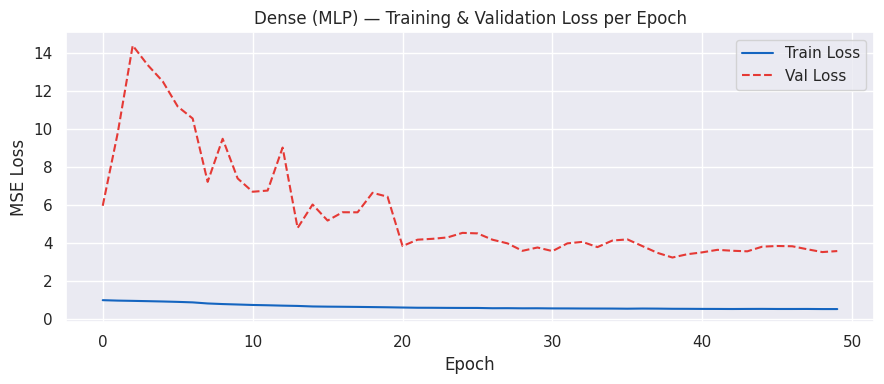

In [79]:
plot_loss(history_dense, "Dense (MLP)")

In [80]:
results_dense = evaluate_model(dense_model, X_test_flat, y_test_t, target_scaler, DEVICE)
print("Dense — MAE:  {:.6f}".format(results_dense["MAE"]))
print("Dense — RMSE: {:.6f}".format(results_dense["RMSE"]))
print("Dense — MAPE: {:.4f}%".format(results_dense["MAPE"]))
print("Dense — R²:   {:.4f}".format(results_dense["R2"]))
print("Dense — DA:   {:.2f}%".format(results_dense["DA%"]))


Dense — MAE:  0.000949
Dense — RMSE: 0.001038
Dense — MAPE: 96962.3203%
Dense — R²:   -8.5523
Dense — DA:   48.96%


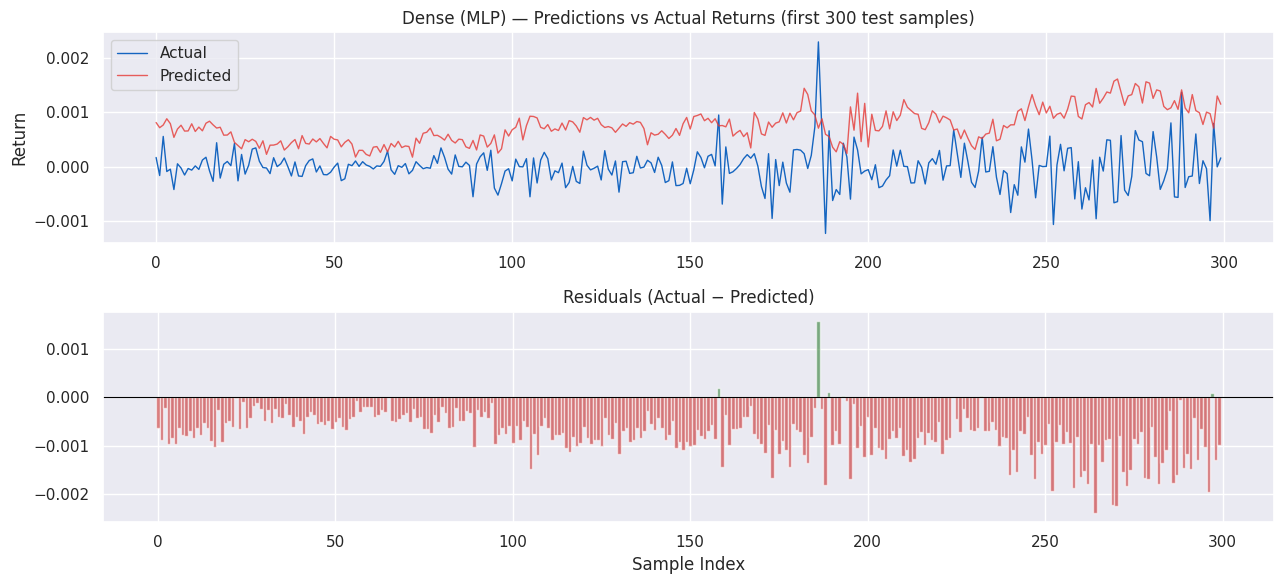

In [81]:
plot_predictions(results_dense["y_true"], results_dense["y_pred"], "Dense (MLP)")

## Section 8 — LSTM Neural Network

In [82]:
# Build an LSTM network using standalone nn.LSTM and nn.Linear
#       modules connected by a procedural forward function.
# Long Short-Term Memory (LSTM) networks are designed specifically
#       for sequential data. They use three gating mechanisms (input,
#       forget, output gates) to selectively retain or discard information
#       across many timesteps. This makes them far more capable than a
#       Dense network at capturing temporal dependencies in the window —
#       for example, learning that a pattern over the past 10 bars
#       predicts the next return. Two stacked LSTM layers allow the
#       second layer to learn higher-order temporal patterns from the
#       representations produced by the first layer. Dropout between
#       layers prevents overfitting in the deeper network.
# nn.LSTM is instantiated as a standalone variable. A plain Python
#       function (_lstm_forward) is attached as the model's forward method
#       using types.MethodType, avoiding any class definition. The hidden
#       state h from the last time step of the last layer contains the
#       network's summary of the entire input sequence, which is then
#       projected to a scalar by the linear layer.

input_size = X_train.shape[2]

lstm_rnn  = nn.LSTM(input_size=input_size, hidden_size=128, num_layers=2,
                    batch_first=True, dropout=0.2).to(DEVICE)
lstm_drop = nn.Dropout(0.2).to(DEVICE)
lstm_fc   = nn.Linear(128, 1).to(DEVICE)

lstm_model = nn.Sequential()

def _lstm_forward(self, x):
    _, (h, _) = lstm_rnn(x)    # h shape: (num_layers, batch, hidden_size)
    out = lstm_drop(h[-1])     # take the last layer's hidden state
    return lstm_fc(out)

lstm_model.forward = types.MethodType(_lstm_forward, lstm_model)
lstm_params = list(lstm_rnn.parameters()) + list(lstm_drop.parameters()) + list(lstm_fc.parameters())
print(f"LSTM parameters: {sum(p.numel() for p in lstm_params):,}")


LSTM parameters: 210,049


In [83]:
optimizer_lstm = optim.Adam(lstm_params, lr=LEARNING_RATE, weight_decay=1e-5)
print("Training LSTM model...")
history_lstm = train_model(lstm_model, train_loader, val_loader, optimizer_lstm, DEVICE)


Training LSTM model...
  Epoch   1/50 | Train: 1.002439 | Val: 1.257042 | LR: 1.00e-03
  Epoch  10/50 | Train: 0.986465 | Val: 1.286280 | LR: 5.00e-04
  Early stopping at epoch 16
  Best val loss: 1.257042


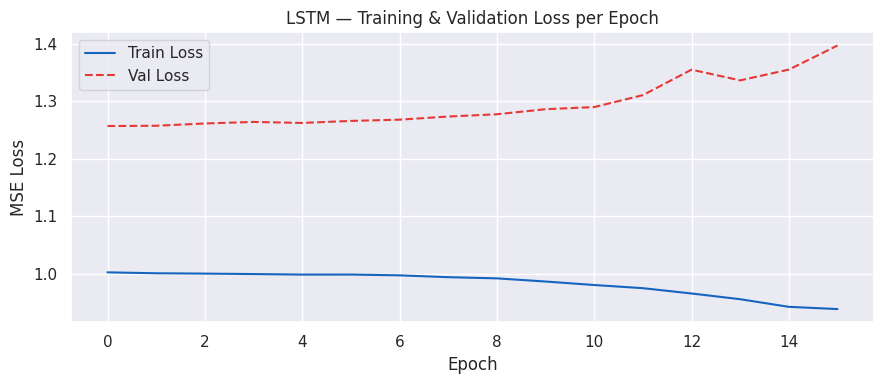

In [84]:
plot_loss(history_lstm, "LSTM")

In [85]:
results_lstm = evaluate_model(lstm_model, X_test_t, y_test_t, target_scaler, DEVICE)
print("LSTM — MAE:  {:.6f}".format(results_lstm["MAE"]))
print("LSTM — RMSE: {:.6f}".format(results_lstm["RMSE"]))
print("LSTM — MAPE: {:.4f}%".format(results_lstm["MAPE"]))
print("LSTM — R²:   {:.4f}".format(results_lstm["R2"]))
print("LSTM — DA:   {:.2f}%".format(results_lstm["DA%"]))


LSTM — MAE:  0.000219
LSTM — RMSE: 0.000340
LSTM — MAPE: 1923.0015%
LSTM — R²:   -0.0257
LSTM — DA:   49.85%


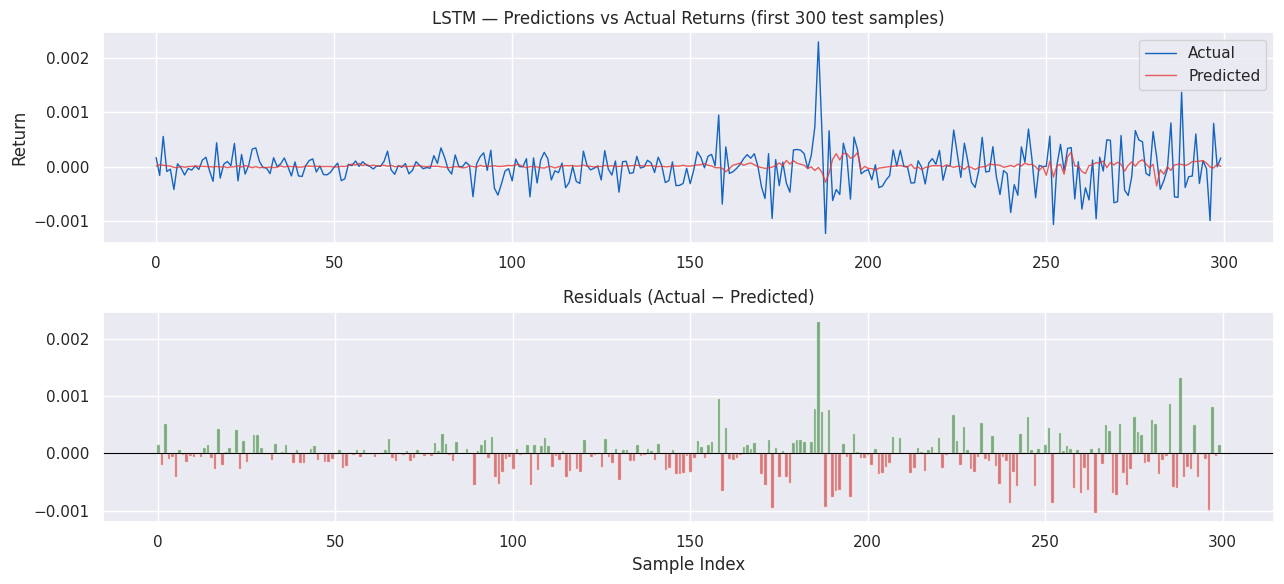

In [86]:
plot_predictions(results_lstm["y_true"], results_lstm["y_pred"], "LSTM")

## Section 9 — GRU Neural Network

In [87]:
# Build a GRU network using the same procedural pattern as the LSTM.
# Gated Recurrent Unit (GRU) is a simplified variant of LSTM that
#       merges the input and forget gates into a single update gate and
#       eliminates the separate cell state. This reduces the number of
#       parameters by roughly 25% compared to an equivalent LSTM, which
#       speeds up training and can reduce overfitting on smaller datasets.
#       GRU often matches or exceeds LSTM performance on financial time
#       series, making it a strong baseline for comparison.
# nn.GRU returns output and the final hidden state h. Unlike LSTM,
#       there is no cell state c, so the output is unpacked as (_, h).
#       The rest of the construction mirrors the LSTM pattern exactly.

gru_rnn  = nn.GRU(input_size=input_size, hidden_size=128, num_layers=2,
                  batch_first=True, dropout=0.2).to(DEVICE)
gru_drop = nn.Dropout(0.2).to(DEVICE)
gru_fc   = nn.Linear(128, 1).to(DEVICE)

gru_model = nn.Sequential()

def _gru_forward(self, x):
    _, h = gru_rnn(x)          # h shape: (num_layers, batch, hidden_size)
    out  = gru_drop(h[-1])     # last layer hidden state
    return gru_fc(out)

gru_model.forward = types.MethodType(_gru_forward, gru_model)
gru_params = list(gru_rnn.parameters()) + list(gru_drop.parameters()) + list(gru_fc.parameters())
print(f"GRU parameters: {sum(p.numel() for p in gru_params):,}")


GRU parameters: 157,569


In [88]:
optimizer_gru = optim.Adam(gru_params, lr=LEARNING_RATE, weight_decay=1e-5)
print("Training GRU model...")
history_gru = train_model(gru_model, train_loader, val_loader, optimizer_gru, DEVICE)


Training GRU model...
  Epoch   1/50 | Train: 1.006226 | Val: 1.267069 | LR: 1.00e-03
  Epoch  10/50 | Train: 0.987069 | Val: 1.308129 | LR: 5.00e-04
  Early stopping at epoch 17
  Best val loss: 1.260939


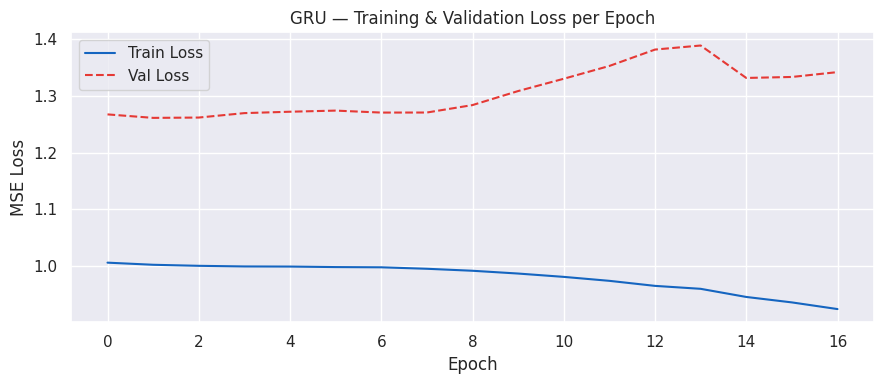

In [89]:
plot_loss(history_gru, "GRU")

In [90]:
results_gru = evaluate_model(gru_model, X_test_t, y_test_t, target_scaler, DEVICE)
print("GRU — MAE:  {:.6f}".format(results_gru["MAE"]))
print("GRU — RMSE: {:.6f}".format(results_gru["RMSE"]))
print("GRU — MAPE: {:.4f}%".format(results_gru["MAPE"]))
print("GRU — R²:   {:.4f}".format(results_gru["R2"]))
print("GRU — DA:   {:.2f}%".format(results_gru["DA%"]))


GRU — MAE:  0.000223
GRU — RMSE: 0.000345
GRU — MAPE: 5179.8628%
GRU — R²:   -0.0529
GRU — DA:   50.57%


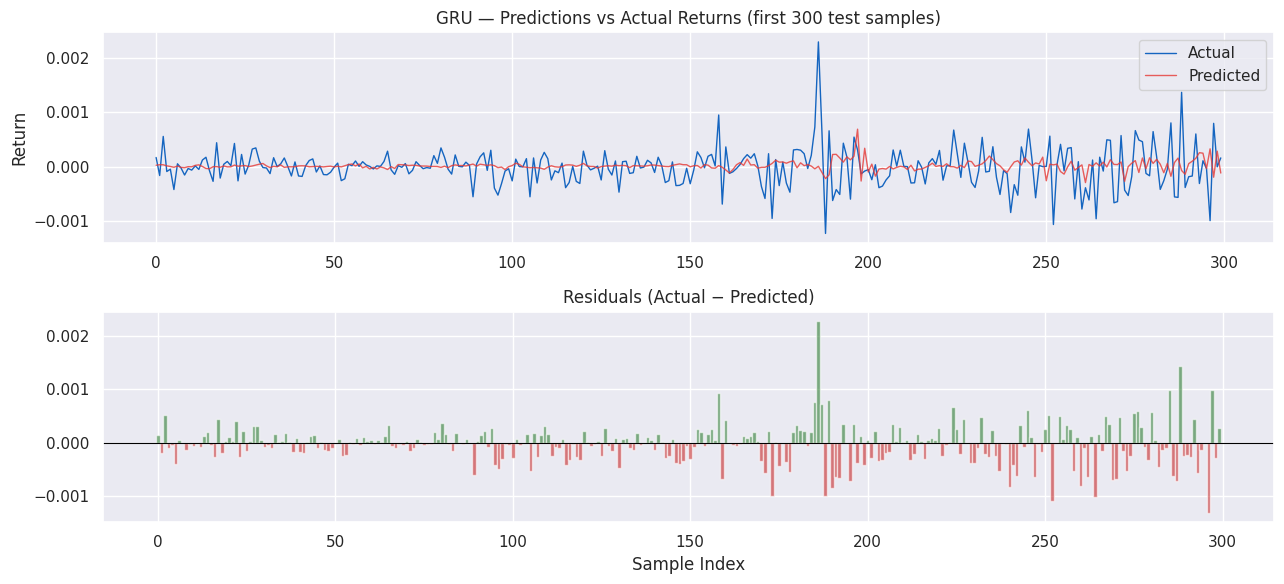

In [91]:
plot_predictions(results_gru["y_true"], results_gru["y_pred"], "GRU")

## Section 10 — GRU Hyperparameter Optimisation

In [92]:
# Define a grid of GRU configurations varying hidden size,
#       number of stacked layers, and learning rate.
# A single manually chosen configuration may not be optimal.
#       Grid search systematically evaluates all combinations so the best
#       configuration is found empirically rather than by guesswork.
#       Hidden size controls the model's memory capacity — too small
#       and it underfits; too large and it overfits. More layers
#       capture more abstract temporal representations but risk overfitting.
#       Learning rate governs convergence speed and stability.
# Each entry in gru_param_grid is a dictionary of hyperparameters.
#       The search loop instantiates a fresh GRU for each configuration,
#       trains it fully, and records the best validation loss achieved.

gru_param_grid = [
    {"hidden_size": 64,  "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 2, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 1, "lr": 5e-4},
    {"hidden_size": 256, "num_layers": 1, "lr": 5e-4},
    {"hidden_size": 128, "num_layers": 2, "lr": 5e-4},
]
print(f"Searching {len(gru_param_grid)} GRU configurations...")


Searching 6 GRU configurations...


In [93]:
# Run the grid search — train one GRU per configuration and
#       track the best-performing model.
# Each model is trained from scratch with fresh random weights
#       so the comparison is fair. The best model is identified by the
#       lowest best validation loss (not the final epoch's loss, which
#       may have increased slightly before early stopping).
# For each config, a new GRU is built procedurally and a closure
#       captures its specific layer variables. After all configs are
#       tested, best_gru_model holds the trained weights of the winner.

tuning_results  = []
best_val_loss   = float("inf")
best_gru_model  = None
best_gru_config = None
best_gru_hist   = None

for i, params in enumerate(gru_param_grid):
    print(f"\nConfig {i+1}/{len(gru_param_grid)}: {params}")

    g_rnn  = nn.GRU(input_size=input_size,
                    hidden_size=params["hidden_size"],
                    num_layers=params["num_layers"],
                    batch_first=True,
                    dropout=0.2 if params["num_layers"] > 1 else 0.0).to(DEVICE)
    g_drop = nn.Dropout(0.2).to(DEVICE)
    g_fc   = nn.Linear(params["hidden_size"], 1).to(DEVICE)

    g_model = nn.Sequential()

    def _fwd(self, x, _r=g_rnn, _d=g_drop, _f=g_fc):
        _, h = _r(x)
        return _f(_d(h[-1]))

    g_model.forward = types.MethodType(_fwd, g_model)
    g_optim = optim.Adam(list(g_rnn.parameters()) + list(g_drop.parameters()) +
                         list(g_fc.parameters()), lr=params["lr"], weight_decay=1e-5)

    h = train_model(g_model, train_loader, val_loader, g_optim, DEVICE)

    best_epoch_val = min(h["val_loss"])
    tuning_results.append({**params, "best_val_loss": best_epoch_val})

    if best_epoch_val < best_val_loss:
        best_val_loss   = best_epoch_val
        best_gru_model  = g_model
        best_gru_config = params
        best_gru_hist   = h

print("\nBest config:", best_gru_config)
print("Best val loss: {:.6f}".format(best_val_loss))



Config 1/6: {'hidden_size': 64, 'num_layers': 1, 'lr': 0.001}
  Epoch   1/50 | Train: 1.008841 | Val: 1.265479 | LR: 1.00e-03
  Epoch  10/50 | Train: 0.987729 | Val: 1.284776 | LR: 5.00e-04
  Early stopping at epoch 17
  Best val loss: 1.264832

Config 2/6: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.001}
  Epoch   1/50 | Train: 1.008016 | Val: 1.266918 | LR: 1.00e-03
  Epoch  10/50 | Train: 0.976792 | Val: 1.311530 | LR: 5.00e-04
  Early stopping at epoch 17
  Best val loss: 1.266097

Config 3/6: {'hidden_size': 128, 'num_layers': 2, 'lr': 0.001}
  Epoch   1/50 | Train: 1.005770 | Val: 1.264405 | LR: 1.00e-03
  Epoch  10/50 | Train: 0.982259 | Val: 1.309420 | LR: 5.00e-04
  Early stopping at epoch 16
  Best val loss: 1.264405

Config 4/6: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0005}
  Epoch   1/50 | Train: 1.006224 | Val: 1.267079 | LR: 5.00e-04
  Epoch  10/50 | Train: 0.989147 | Val: 1.280173 | LR: 2.50e-04
  Early stopping at epoch 17
  Best val loss: 1.262292

Config 5/6:

In [94]:
# Display the grid search results sorted by validation loss.
# A sorted table makes it easy to see which hyperparameters
#       produced the best and worst results, and whether there is a
#       clear trend (e.g., larger hidden size consistently wins, or
#       lower learning rate consistently wins).
# The tuning_results list of dicts is converted to a DataFrame
#       and sorted ascending by best_val_loss.

tuning_df = pd.DataFrame(tuning_results).sort_values("best_val_loss").reset_index(drop=True)
print(tuning_df.to_string())


   hidden_size  num_layers      lr  best_val_loss
0          128           2  0.0005       1.259276
1          128           1  0.0005       1.262292
2          128           2  0.0010       1.264405
3           64           1  0.0010       1.264832
4          256           1  0.0005       1.265332
5          128           1  0.0010       1.266097


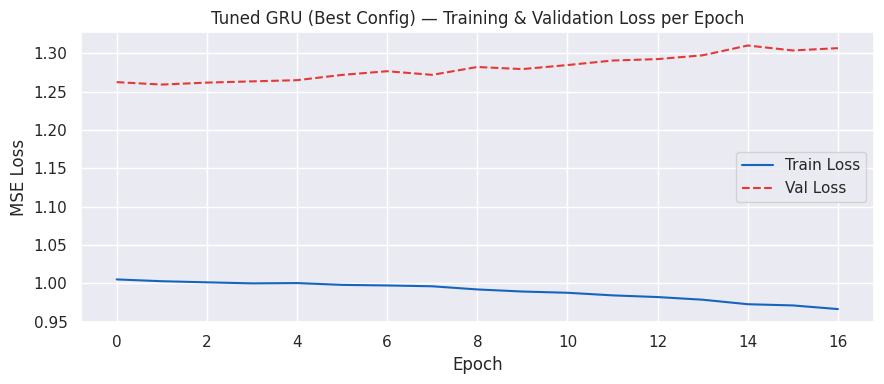

In [95]:
plot_loss(best_gru_hist, "Tuned GRU (Best Config)")

In [96]:
results_tuned_gru = evaluate_model(best_gru_model, X_test_t, y_test_t, target_scaler, DEVICE)
print("Tuned GRU — MAE:  {:.6f}".format(results_tuned_gru["MAE"]))
print("Tuned GRU — RMSE: {:.6f}".format(results_tuned_gru["RMSE"]))
print("Tuned GRU — MAPE: {:.4f}%".format(results_tuned_gru["MAPE"]))
print("Tuned GRU — R²:   {:.4f}".format(results_tuned_gru["R2"]))
print("Tuned GRU — DA:   {:.2f}%".format(results_tuned_gru["DA%"]))


Tuned GRU — MAE:  0.000218
Tuned GRU — RMSE: 0.000339
Tuned GRU — MAPE: 2578.2886%
Tuned GRU — R²:   -0.0215
Tuned GRU — DA:   50.90%


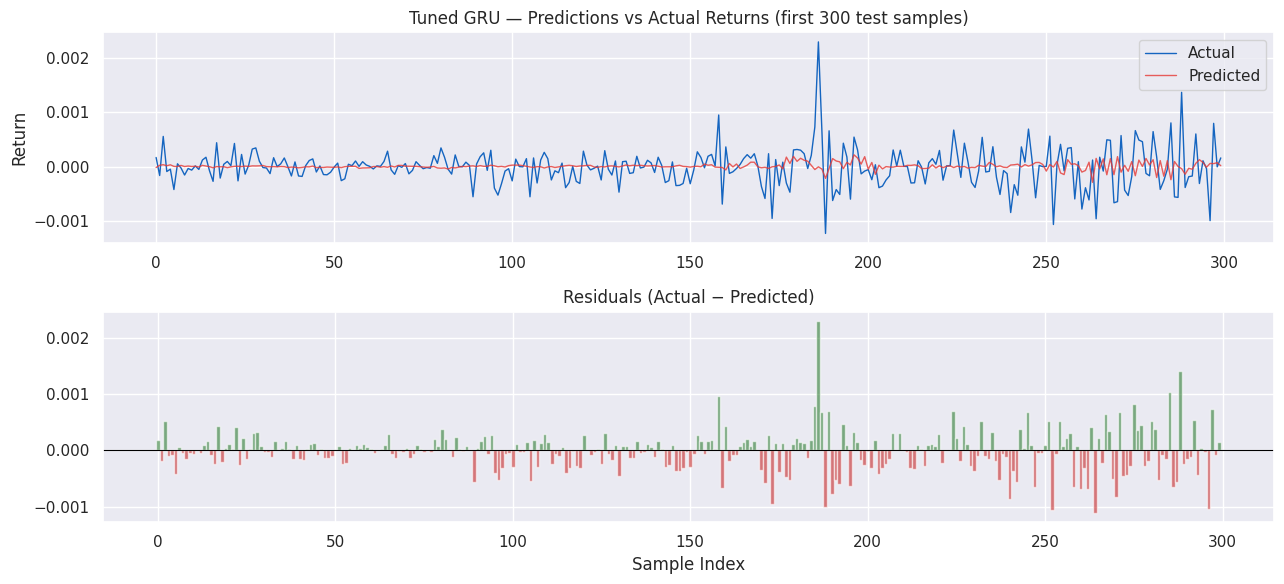

In [97]:
plot_predictions(results_tuned_gru["y_true"], results_tuned_gru["y_pred"], "Tuned GRU")

## Section 11 — Transformer Encoder Network

In [98]:
# Compute a fixed sinusoidal positional encoding matrix for
#       the Transformer model.
# Unlike RNNs, the Transformer processes all timesteps in parallel
#       and has no built-in sense of order. Without positional encoding,
#       it treats the sequence as an unordered set — it would not know
#       whether timestep 1 came before timestep 20. Positional encoding
#       injects time position information by adding a unique pattern of
#       sine and cosine waves (at different frequencies) to each position's
#       embedding, allowing the model to distinguish positions.
# For each position p and each dimension d, the encoding is
#       sin(p / 10000^(2d/D_MODEL)) for even dimensions and
#       cos(p / 10000^(2d/D_MODEL)) for odd dimensions. The result
#       is a (1, seq_len, D_MODEL) tensor added to the projected input.

def positional_encoding(seq_len, d_model):
    pe       = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
    return pe.unsqueeze(0)   # (1, seq_len, d_model)

print("Positional encoding function defined.")
print("Shape:", positional_encoding(WINDOW_SIZE, 64).shape)


Positional encoding function defined.
Shape: torch.Size([1, 20, 64])


In [99]:
# Build a Transformer Encoder network using nn.TransformerEncoderLayer
#       and nn.TransformerEncoder, connected procedurally.
# The Transformer uses multi-head self-attention to directly model
#       relationships between all pairs of timesteps in the window, rather
#       than processing them sequentially like an LSTM/GRU. This allows it
#       to capture long-range dependencies more efficiently. Each attention
#       head learns a different type of relationship (e.g., one head may
#       learn to attend to high-volatility bars, another to MA crossovers).
#       A linear projection first maps the input_size features to D_MODEL
#       dimensions so the multi-head attention can split evenly across heads.
#       Global average pooling over the time axis aggregates all timestep
#       representations into a single vector before the output layer.
# D_MODEL must be divisible by N_HEAD. TransformerEncoderLayer
#       implements one self-attention + feed-forward block. TransformerEncoder
#       stacks N_LAYERS of these blocks. AdaptiveAvgPool1d(1) reduces
#       the time dimension to 1 by averaging.

D_MODEL  = 64
N_HEAD   = 4
N_LAYERS = 2

tfm_proj      = nn.Linear(input_size, D_MODEL).to(DEVICE)
tfm_enc_layer = nn.TransformerEncoderLayer(
    d_model=D_MODEL, nhead=N_HEAD, dim_feedforward=128,
    dropout=0.1, batch_first=True
).to(DEVICE)
tfm_encoder   = nn.TransformerEncoder(tfm_enc_layer, num_layers=N_LAYERS).to(DEVICE)
tfm_pool      = nn.AdaptiveAvgPool1d(1)
tfm_fc        = nn.Linear(D_MODEL, 1).to(DEVICE)

pe_fixed = positional_encoding(WINDOW_SIZE, D_MODEL).to(DEVICE)

tfm_model = nn.Sequential()

def _tfm_forward(self, x):
    x = tfm_proj(x)               # (batch, seq, D_MODEL)
    x = x + pe_fixed              # add positional encoding
    x = tfm_encoder(x)            # self-attention layers
    x = x.permute(0, 2, 1)        # (batch, D_MODEL, seq)
    x = tfm_pool(x).squeeze(-1)   # global average pool → (batch, D_MODEL)
    return tfm_fc(x)              # (batch, 1)

tfm_model.forward = types.MethodType(_tfm_forward, tfm_model)
tfm_params = (list(tfm_proj.parameters()) + list(tfm_encoder.parameters()) +
              list(tfm_fc.parameters()))
print(f"Transformer parameters: {sum(p.numel() for p in tfm_params):,}")


Transformer parameters: 68,481


In [100]:
# Train the Transformer with a slightly lower learning rate.
# Transformers are more sensitive to learning rate than RNNs because
#       their attention weights can diverge quickly with a large step size.
#       A lower initial rate (5e-4) combined with the ReduceLROnPlateau
#       scheduler provides stable convergence.
# Same shared train_model function, just with a different optimizer
#       instance carrying the lower learning rate.

optimizer_tfm = optim.Adam(tfm_params, lr=5e-4, weight_decay=1e-5)
print("Training Transformer model...")
history_tfm = train_model(tfm_model, train_loader, val_loader, optimizer_tfm, DEVICE)


Training Transformer model...
  Epoch   1/50 | Train: 1.022060 | Val: 1.298179 | LR: 5.00e-04
  Epoch  10/50 | Train: 1.003552 | Val: 1.259236 | LR: 2.50e-04
  Epoch  20/50 | Train: 0.982918 | Val: 1.263347 | LR: 1.25e-04
  Early stopping at epoch 26
  Best val loss: 1.257532


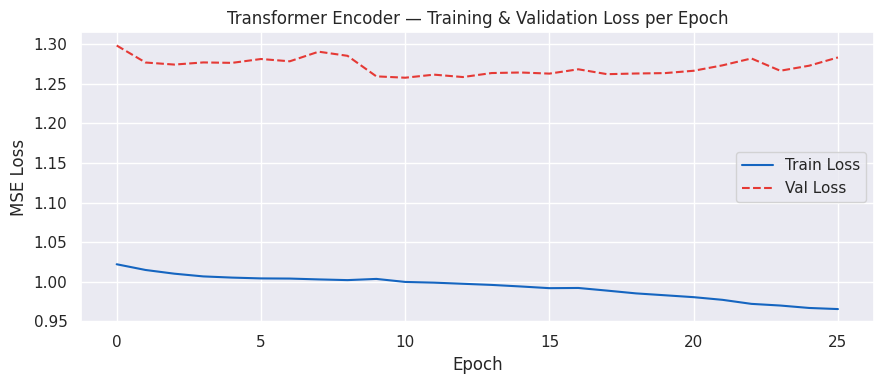

In [101]:
plot_loss(history_tfm, "Transformer Encoder")

In [102]:
results_tfm = evaluate_model(tfm_model, X_test_t, y_test_t, target_scaler, DEVICE)
print("Transformer — MAE:  {:.6f}".format(results_tfm["MAE"]))
print("Transformer — RMSE: {:.6f}".format(results_tfm["RMSE"]))
print("Transformer — MAPE: {:.4f}%".format(results_tfm["MAPE"]))
print("Transformer — R²:   {:.4f}".format(results_tfm["R2"]))
print("Transformer — DA:   {:.2f}%".format(results_tfm["DA%"]))


Transformer — MAE:  0.000226
Transformer — RMSE: 0.000349
Transformer — MAPE: 6426.0293%
Transformer — R²:   -0.0780
Transformer — DA:   49.67%


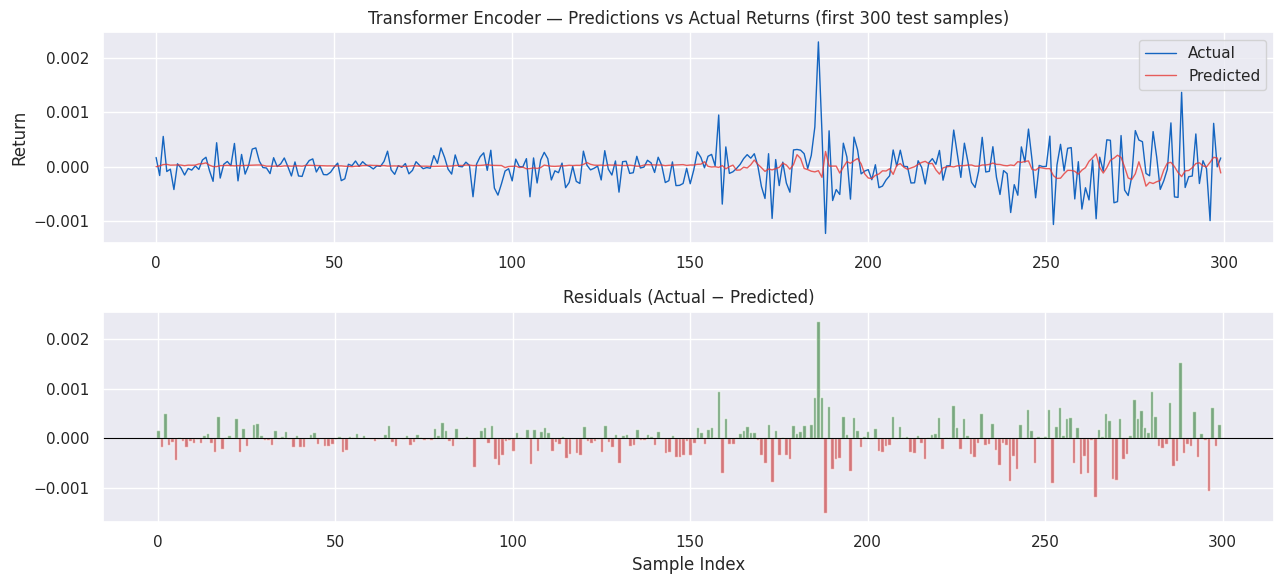

In [103]:
plot_predictions(results_tfm["y_true"], results_tfm["y_pred"], "Transformer Encoder")

## Section 12 — Final Model Comparison & Advanced Visualisations

In [104]:
# Assemble a comparison table of all five models across five metrics.
# A consolidated table allows direct, side-by-side comparison that
#       would be impossible from five separate print statements. Sorting
#       by RMSE gives a clear ranking of overall prediction accuracy.
# A list comprehension builds one dict per model from the results
#       dicts, then pd.DataFrame converts it to a table.

model_names = ["Dense (MLP)", "LSTM", "GRU", "Tuned GRU", "Transformer"]
all_results = [results_dense, results_lstm, results_gru, results_tuned_gru, results_tfm]

comparison = pd.DataFrame([
    {"Model": name, "MAE": r["MAE"], "RMSE": r["RMSE"],
     "MAPE %": r["MAPE"], "R²": r["R2"], "DA %": r["DA%"]}
    for name, r in zip(model_names, all_results)
]).sort_values("RMSE").reset_index(drop=True)

comparison.round(6)


,Model,MAE,RMSE,MAPE %,R²,DA %
0,Tuned GRU,0.000218,0.000339,2578.288574,-0.021474,50.895928
1,LSTM,0.000219,0.000340,1923.001465,-0.025719,49.846154
2,GRU,0.000223,0.000345,5179.863281,-0.052875,50.570136
3,Transformer,0.000226,0.000349,6426.029297,-0.077962,49.665158
4,Dense (MLP),0.000949,0.001038,96962.320312,-8.552339,48.959276


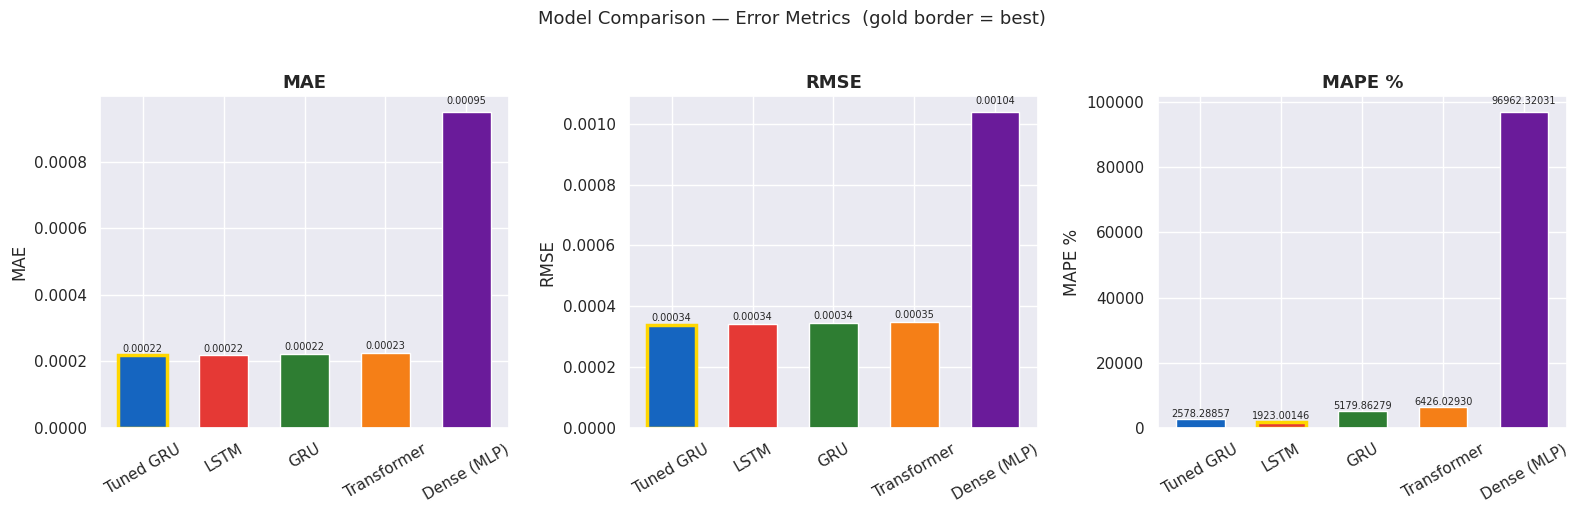

In [105]:
# Plot a grouped bar chart for MAE, RMSE, and MAPE across all models,
#       with the best model in each metric highlighted with a gold border.
# Bar charts make magnitude differences between models immediately
#       visible. Highlighting the best bar draws attention to the winner
#       without requiring the reader to read all the numbers.
# np.argmin finds the index of the lowest bar in each metric subplot.
#       set_edgecolor and set_linewidth apply the gold highlight to that bar.
#       Text annotations above each bar show the exact numeric value.

colours = ["#1565C0","#E53935","#2E7D32","#F57F17","#6A1B9A"]
metrics = ["MAE","RMSE","MAPE %"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, metrics):
    vals = comparison[metric].values
    bars = ax.bar(comparison["Model"], vals, color=colours, edgecolor="white", width=0.6)
    best = int(np.argmin(vals))
    bars[best].set_edgecolor("gold"); bars[best].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                f"{v:.5f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric); ax.tick_params(axis="x", rotation=30)

plt.suptitle("Model Comparison — Error Metrics  (gold border = best)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


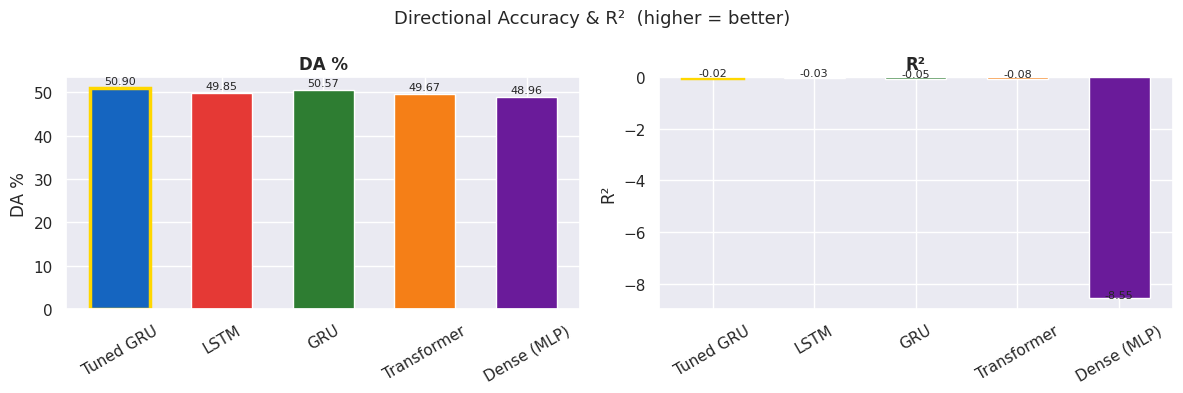

In [106]:
# Plot Directional Accuracy and R² for all models.
# DA and R² are "higher is better" metrics, which is the opposite
#       convention to MAE/RMSE. Showing them separately avoids confusion
#       about which direction is good. DA is especially important for
#       trading applications because a model with low RMSE but DA below
#       50% would produce losing trades on average.
# np.argmax identifies the best bar (highest value) rather than
#       the lowest, consistent with the "higher is better" convention.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["DA %", "R²"]):
    vals = comparison[metric].values
    bars = ax.bar(comparison["Model"], vals, color=colours, edgecolor="white", width=0.6)
    best = int(np.argmax(vals))
    bars[best].set_edgecolor("gold"); bars[best].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric); ax.tick_params(axis="x", rotation=30)

plt.suptitle("Directional Accuracy & R²  (higher = better)", fontsize=13)
plt.tight_layout(); plt.show()


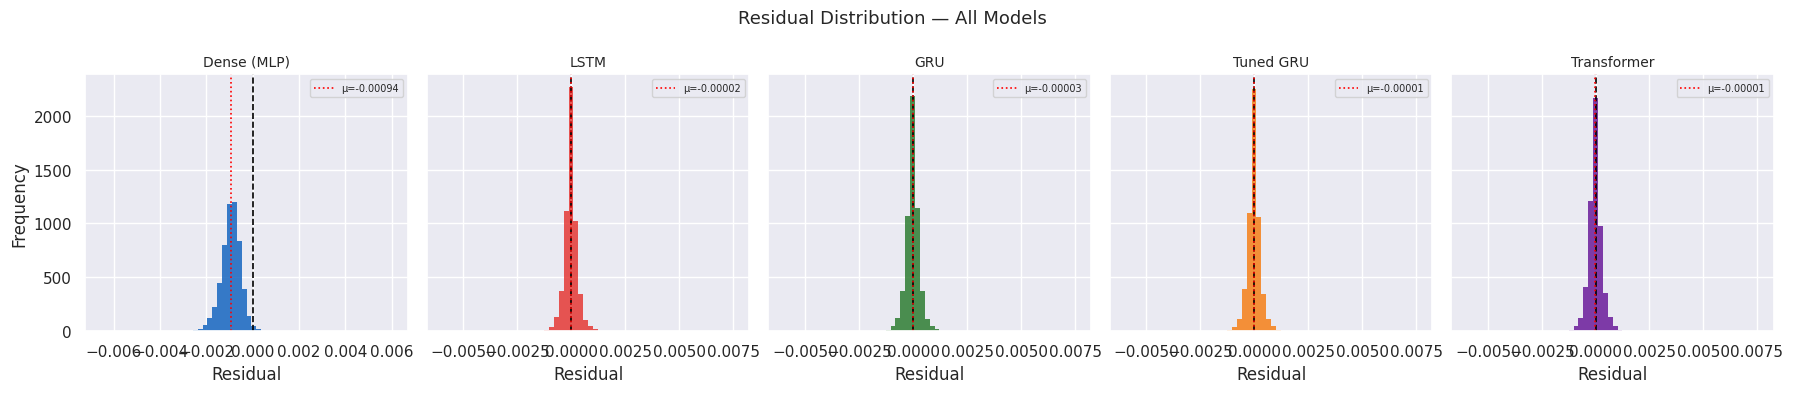

In [107]:
# Plot the residual (error) distribution for each model as a
#       histogram with a mean line.
# A well-calibrated model should produce residuals that are
#       approximately normally distributed and centred at zero. A mean
#       far from zero indicates a systematic bias — the model consistently
#       over- or under-predicts. Heavy tails indicate the model makes
#       very large errors more often than expected. Comparing these
#       distributions across models reveals which architectures produce
#       more reliable, unbiased errors.
# residuals = actual - predicted. axvline at 0 shows the ideal
#       centre. A second axvline at the mean shows actual bias.

fig, axes = plt.subplots(1, len(model_names), figsize=(18, 4), sharey=True)
for ax, name, r, col in zip(axes, model_names, all_results, colours):
    res = r["y_true"] - r["y_pred"]
    ax.hist(res, bins=60, color=col, edgecolor="none", alpha=0.85)
    ax.axvline(0,        color="black", lw=1.2, linestyle="--")
    ax.axvline(res.mean(), color="red", lw=1.2, linestyle=":", label=f"μ={res.mean():.5f}")
    ax.set_title(name, fontsize=10); ax.set_xlabel("Residual"); ax.legend(fontsize=7)
axes[0].set_ylabel("Frequency")
plt.suptitle("Residual Distribution — All Models", fontsize=13)
plt.tight_layout(); plt.show()


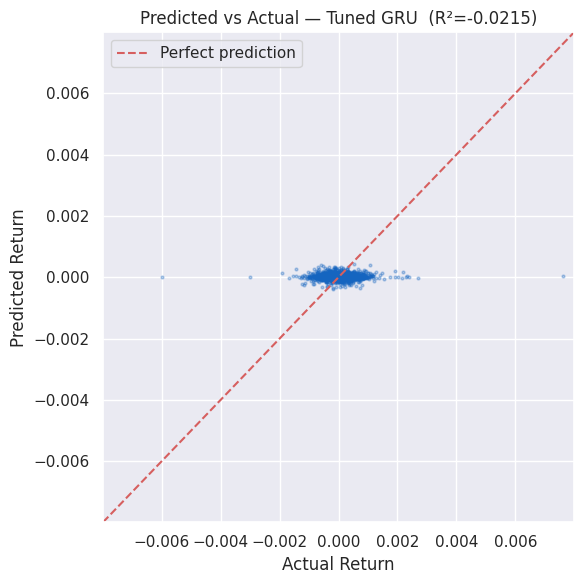

In [108]:
# Plot a predicted vs actual scatter plot for the best model.
# A scatter plot directly shows the relationship between predicted
#       and actual values. If the model were perfect, all points would
#       lie on the y=x diagonal (the red dashed line). Points scattered
#       symmetrically around the diagonal with no curved pattern indicate
#       a well-fitted linear relationship. Curved patterns would indicate
#       the model is missing non-linear structure.
# The best model is identified from the sorted comparison table.
#       model_names.index() finds its position to retrieve the correct
#       results dict.

best_name   = comparison.iloc[0]["Model"]
best_result = all_results[model_names.index(best_name)]
y_t, y_p    = best_result["y_true"], best_result["y_pred"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_t, y_p, alpha=0.3, s=4, color="#1565C0")
lim = max(abs(y_t).max(), abs(y_p).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.5, label="Perfect prediction")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("Actual Return"); ax.set_ylabel("Predicted Return")
ax.set_title(f"Predicted vs Actual — {best_name}  (R²={best_result['R2']:.4f})")
ax.legend(); plt.tight_layout(); plt.show()


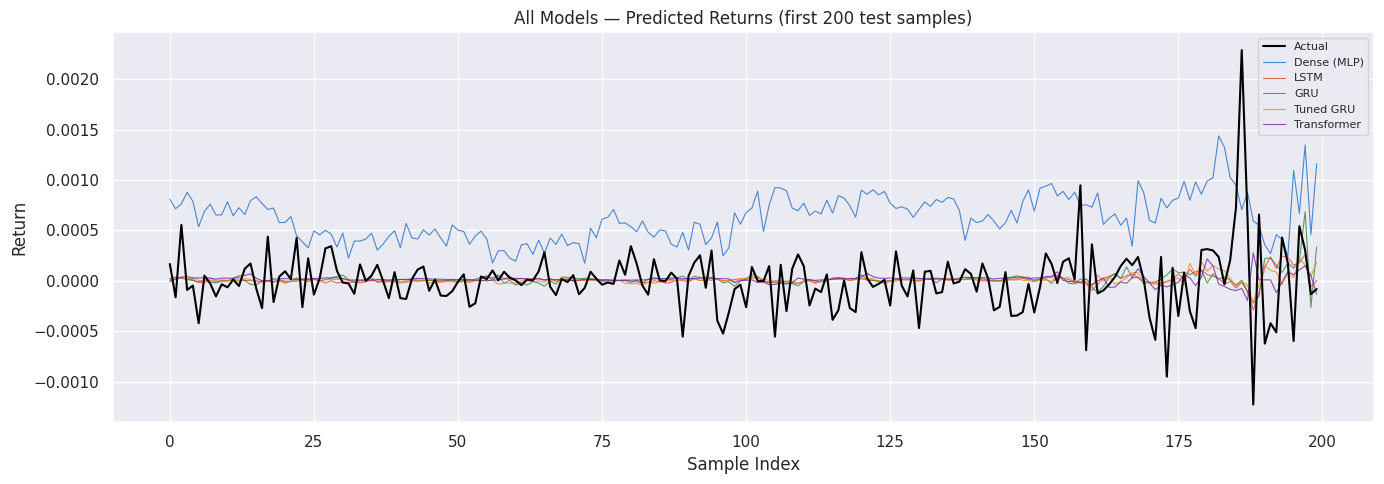

In [109]:
# Overlay all five models' test predictions on a shared axis
#       alongside the actual returns.
# Overlaying predictions shows not just accuracy but agreement —
#       do all models make the same mistakes at the same time (suggesting
#       the signal is genuinely hard to predict at those points), or do
#       models fail at different times (suggesting ensemble averaging
#       could reduce errors)?
# Each model's y_pred is plotted on the same axes. The actual
#       series is drawn in black with higher line width to stand out.

n_plot = 200
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results_dense["y_true"][:n_plot], color="black", lw=1.5, label="Actual", zorder=5)
for name, r, col in zip(model_names, all_results, colours):
    ax.plot(r["y_pred"][:n_plot], color=col, lw=0.8, alpha=0.75, label=name)
ax.set_title(f"All Models — Predicted Returns (first {n_plot} test samples)")
ax.set_xlabel("Sample Index"); ax.set_ylabel("Return")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()


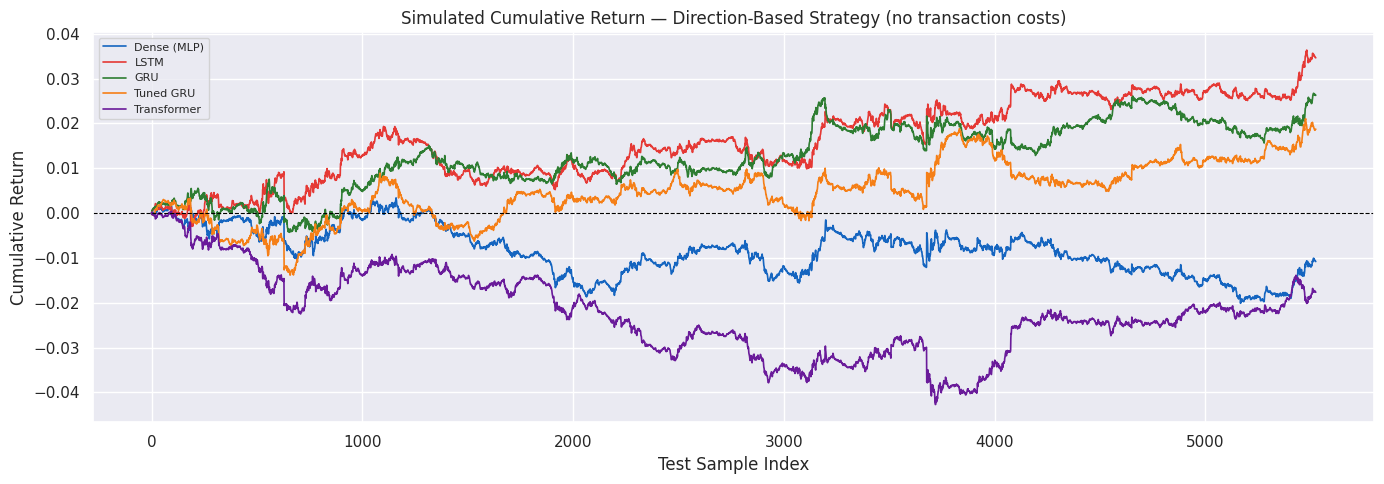

In [110]:
# Simulate a simple direction-based trading strategy for each model
#       and plot cumulative returns over the test period.
# Error metrics like RMSE measure prediction accuracy but not
#       trading profitability. A model with higher RMSE could still be
#       more profitable if it gets the direction right more often on
#       large moves. This simulation assigns a long position (+1) when
#       the model predicts a positive return and a short position (-1)
#       when it predicts negative, then multiplies by the actual return
#       to compute strategy profit per bar.
# np.sign extracts +1 or -1 from the prediction. Element-wise
#       multiplication with actual returns gives the strategy return
#       per bar. np.cumsum accumulates these over time.

fig, ax = plt.subplots(figsize=(14, 5))
actual_returns = results_dense["y_true"]

for name, r, col in zip(model_names, all_results, colours):
    strategy = np.sign(r["y_pred"]) * actual_returns
    ax.plot(np.cumsum(strategy), color=col, lw=1.2, label=name)

ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_title("Simulated Cumulative Return — Direction-Based Strategy (no transaction costs)")
ax.set_xlabel("Test Sample Index"); ax.set_ylabel("Cumulative Return")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Section 13 — Summary & Conclusions

In [112]:
# Print the final ranked comparison table and identify the
#       best-performing model across all metrics.
# A clear summary allows the reader to identify the model that
#       should be deployed or studied further without having to cross-
#       reference multiple earlier cells.
# The comparison DataFrame is already sorted by RMSE. iloc[0]
#       retrieves the top-ranked row.

print("=" * 65)
print("     FINAL MODEL PERFORMANCE SUMMARY (sorted by RMSE)")
print("=" * 65)
print(comparison.to_string(index=True))
print("=" * 65)

best = comparison.iloc[0]
print(f"\nBest model:  {best['Model']}")
print(f"  RMSE = {best['RMSE']:.6f}")
print(f"  R²   = {best['R²']:.4f}")
print(f"  DA   = {best['DA %']:.2f}%")

     FINAL MODEL PERFORMANCE SUMMARY (sorted by RMSE)
         Model       MAE      RMSE        MAPE %        R²       DA %
0    Tuned GRU  0.000218  0.000339   2578.288574 -0.021474  50.895928
1         LSTM  0.000219  0.000340   1923.001465 -0.025719  49.846154
2          GRU  0.000223  0.000345   5179.862793 -0.052875  50.570136
3  Transformer  0.000226  0.000349   6426.029297 -0.077962  49.665158
4  Dense (MLP)  0.000949  0.001038  96962.320312 -8.552339  48.959276

Best model:  Tuned GRU
  RMSE = 0.000339
  R²   = -0.0215
  DA   = 50.90%
